In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# Dark theme template for all Plotly figures
DARK_TEMPLATE = 'plotly_dark'
DARK_BG = '#111111'
LIGHT_TEXT = '#FFFFFF'

# Exploratory Data Analysis (EDA)
## Mental Health & Lifestyle Factors Study
*Comprehensive analysis of depression severity and health-related variables*

In [2]:
df = pd.read_csv('data.csv')

print('\nDataset Loaded Successfully')
print('=' * 80)
print(f'Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('=' * 80)
df.head()


Dataset Loaded Successfully
Dataset Shape: 5,000 rows x 26 columns


,id,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity
0,user_075722,Italy,230,26,Other,Student,Married,Bachelor,1000–2000€,Occasional,...,False,False,False,False,False,False,NaN,10.0,2.6,Mild
1,user_080185,Italy,230,64,Other,Student,Widowed,High School,2000–3000€,NaN,...,False,False,False,False,True,True,NaN,7.7,2.2,Moderate
2,user_019865,Spain,250,54,Male,Unemployed,Single,Bachelor,>5000€,NaN,...,False,True,True,True,False,False,NaN,8.4,3.8,Mild
3,user_076700,Sweden,170,51,Male,Retired,Divorced,Master,1000–2000€,NaN,...,True,False,False,True,True,True,Moderate,4.2,1.3,Moderate
4,user_092992,France,200,71,Other,Student,Married,Master,2000–3000€,Frequent,...,False,False,True,True,False,True,NaN,2.6,1.8,Severe


In [3]:
rows, cols = df.shape
print('\nDATASET OVERVIEW')
print('=' * 80)
print(f'Total Records  : {rows:,}')
print(f'Total Features : {cols}')
print('\nColumn Names and Types:')
print('-' * 80)

for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    non_null = df[col].notna().sum()
    missing = df[col].isna().sum()
    print(f'{i:2}. {col:<30} | Type: {dtype:<12} | Non-Null: {non_null:>6} | Missing: {missing:>4}')


DATASET OVERVIEW
Total Records  : 5,000
Total Features : 26

Column Names and Types:
--------------------------------------------------------------------------------
 1. id                             | Type: object       | Non-Null:   5000 | Missing:    0
 2. country                        | Type: object       | Non-Null:   5000 | Missing:    0
 3. average_sunny_days             | Type: int64        | Non-Null:   5000 | Missing:    0
 4. age                            | Type: int64        | Non-Null:   5000 | Missing:    0
 5. gender                         | Type: object       | Non-Null:   5000 | Missing:    0
 6. employment_status              | Type: object       | Non-Null:   5000 | Missing:    0
 7. marital_status                 | Type: object       | Non-Null:   5000 | Missing:    0
 8. education_level                | Type: object       | Non-Null:   5000 | Missing:    0
 9. monthly_income                 | Type: object       | Non-Null:   5000 | Missing:    0
10. loneliness

In [4]:
print('\nDATA TYPE CLASSIFICATION')
print('=' * 80)

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'\nNumerical Features ({len(numeric_cols)}):' )
for col in numeric_cols:
    print(f'  {col}')

print(f'\nCategorical Features ({len(categorical_cols)}):' )
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f'  {col:<32} - {unique_count} unique values')


DATA TYPE CLASSIFICATION

Numerical Features (4):
  average_sunny_days
  age
  social_media_use_hours
  news_hours_per_day

Categorical Features (10):
  id                               - 5000 unique values
  country                          - 6 unique values
  gender                           - 3 unique values
  employment_status                - 4 unique values
  marital_status                   - 4 unique values
  education_level                  - 4 unique values
  monthly_income                   - 5 unique values
  loneliness                       - 2 unique values
  anxiety_level                    - 3 unique values
  depression_severity              - 3 unique values


In [5]:
# Feature type distribution visualization
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Feature Type Distribution', 'All Features by Type'),
    specs=[[{'type':'pie'}, {'type':'bar'}]])

type_counts = {'Numerical': len(numeric_cols), 'Categorical': len(categorical_cols)}
fig.add_trace(
    go.Pie(labels=list(type_counts.keys()), 
            values=list(type_counts.values()),
            marker=dict(colors=['#1f77b4', '#ff7f0e']),
            hole=0.3),
    row=1, col=1
)

all_cols_with_types = [(col, 'Numerical') for col in numeric_cols] + \
                      [(col, 'Categorical') for col in categorical_cols]
col_names = [c[0] for c in all_cols_with_types]
col_colors = ['#1f77b4' if c[1] == 'Numerical' else '#ff7f0e' for c in all_cols_with_types]

fig.add_trace(
    go.Bar(y=col_names, x=[1]*len(col_names),
           marker=dict(color=col_colors),
           orientation='h',
           showlegend=False,
           hovertemplate='%{y}<extra></extra>'),
    row=1, col=2
)

fig.update_layout(height=500, title_text='Feature Type Analysis', 
                  title_font_size=14, showlegend=True, template=DARK_TEMPLATE)
fig.update_xaxes(showticklabels=False, row=1, col=2)
fig.show()

In [6]:
print('\nSTATISTICAL SUMMARY - Numerical Features')
print('=' * 80)

stats_summary = df[numeric_cols].describe().round(3)
print(stats_summary.to_string())

print('\nAdditional Statistics:')
print('-' * 80)
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis_val = df[col].kurtosis()
    cv = (df[col].std() / df[col].mean() * 100) if df[col].mean() != 0 else 0
    print(f'{col:<25} | Skewness: {skewness:>7.3f} | Kurtosis: {kurtosis_val:>7.3f} | CV: {cv:>6.2f}%')


STATISTICAL SUMMARY - Numerical Features
       average_sunny_days       age  social_media_use_hours  news_hours_per_day
count            5000.000  5000.000                5000.000            5000.000
mean              193.648    49.027                   4.954               1.994
std                37.097    18.143                   2.890               1.159
min               150.000    18.000                   0.000               0.000
25%               160.000    33.000                   2.400               1.000
50%               200.000    49.000                   5.000               2.000
75%               230.000    64.000                   7.400               3.000
max               250.000    80.000                  10.000               4.000

Additional Statistics:
--------------------------------------------------------------------------------
average_sunny_days        | Skewness:   0.325 | Kurtosis:  -1.458 | CV:  19.16%
age                       | Skewness:  -0.002 | Kurto

In [7]:
print('\nCATEGORICAL FEATURES - Value Distribution')
print('=' * 80)

for col in categorical_cols:
    if col == 'id':
        continue
    unique_vals = df[col].dropna().unique()
    value_counts = df[col].value_counts()
    print(f'\n{col.upper()} ({len(unique_vals)} unique values)')
    print('-' * 80)
    for val, count in value_counts.items():
        pct = (count / len(df) * 100)
        bar_length = int(pct / 2)
        print(f'  {val:<25} : {count:>6} ({pct:>5.1f}%) {"=" * bar_length}')


CATEGORICAL FEATURES - Value Distribution

COUNTRY (6 unique values)
--------------------------------------------------------------------------------
  Spain                     :    872 ( 17.4%) ========
  Netherlands               :    842 ( 16.8%) ========
  Germany                   :    833 ( 16.7%) ========
  France                    :    827 ( 16.5%) ========
  Italy                     :    814 ( 16.3%) ========
  Sweden                    :    812 ( 16.2%) ========

GENDER (3 unique values)
--------------------------------------------------------------------------------
  Male                      :   1696 ( 33.9%) ================
  Other                     :   1684 ( 33.7%) ================
  Female                    :   1620 ( 32.4%) ================

EMPLOYMENT_STATUS (4 unique values)
--------------------------------------------------------------------------------
  Unemployed                :   1283 ( 25.7%) ============
  Retired                   :   1259 ( 25.2%) 

In [8]:
print('\nMISSING VALUES ANALYSIS')
print('=' * 80)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percent': missing_pct
}).sort_values('Missing_Count', ascending=False)

missing_df_display = missing_df[missing_df['Missing_Count'] > 0]

if len(missing_df_display) > 0:
    print('\nColumns with Missing Values:')
    print('-' * 80)
    for col, row in missing_df_display.iterrows():
        print(f'{col:<30} : {int(row["Missing_Count"]):>6} missing ({row["Missing_Percent"]:>5.1f}%)')
    print(f'\nTotal Missing Cells: {missing.sum():,}')
    print(f'Columns Affected: {(missing > 0).sum()} out of {len(df.columns)}')
    print(f'Overall Sparsity: {(missing.sum() / (len(df) * len(df.columns)) * 100):.2f}%')
else:
    print('No missing values detected')


MISSING VALUES ANALYSIS

Columns with Missing Values:
--------------------------------------------------------------------------------
loneliness                     :   1646 missing ( 32.9%)
anxiety_level                  :   1304 missing ( 26.1%)

Total Missing Cells: 2,950
Columns Affected: 2 out of 26
Overall Sparsity: 2.27%


In [9]:
# Missing values visualization
cols_with_missing = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=True)

if len(cols_with_missing) > 0:
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Missing Values Count', 'Missing Values Percentage'),
        specs=[[{'type': 'bar'}, {'type': 'bar'}]]
    )

    fig.add_trace(
        go.Bar(x=cols_with_missing['Missing_Count'], 
               y=cols_with_missing.index,
               orientation='h',
               marker=dict(color='#d62728'),
               name='Count',
               hovertemplate='%{y}: %{x}<extra></extra>'),
        row=1, col=1
    )

    fig.add_trace(
        go.Bar(x=cols_with_missing['Missing_Percent'], 
               y=cols_with_missing.index,
               orientation='h',
               marker=dict(color='#ff7f0e'),
               name='Percentage',
               hovertemplate='%{y}: %{x}%<extra></extra>'),
        row=1, col=2
    )

    fig.update_xaxes(title_text='Count', row=1, col=1)
    fig.update_xaxes(title_text='Percentage (%)', row=1, col=2)
    fig.update_layout(height=400, title_text='Missing Values Distribution',
                      title_font_size=14, showlegend=False, template=DARK_TEMPLATE)
    fig.show()
else:
    print('No visualization needed')

In [10]:
print('\nTARGET VARIABLE ANALYSIS - Depression Severity')
print('=' * 80)

depression = df['depression_severity'].dropna()
depression_counts = df['depression_severity'].value_counts().sort_index()

print(f'\nDepression Severity Distribution:')
print('-' * 80)
for severity, count in depression_counts.items():
    pct = (count / len(depression) * 100)
    bar_length = int(pct / 2)
    print(f'  {severity:<12} : {count:>6} ({pct:>5.1f}%) {"=" * bar_length}')

print(f'\nSummary Statistics:')
print(f'  Total Responses      : {len(depression):,}')
print(f'  Missing Values       : {df["depression_severity"].isna().sum()}')
print(f'  Most Common Severity : {depression_counts.idxmax()}')
print(f'  Distribution         : {dict(depression_counts)}')


TARGET VARIABLE ANALYSIS - Depression Severity

Depression Severity Distribution:
--------------------------------------------------------------------------------
  Mild         :   1630 ( 32.6%) ================
  Moderate     :   1657 ( 33.1%) ================
  Severe       :   1713 ( 34.3%) =================

Summary Statistics:
  Total Responses      : 5,000
  Missing Values       : 0
  Most Common Severity : Severe
  Distribution         : {'Mild': np.int64(1630), 'Moderate': np.int64(1657), 'Severe': np.int64(1713)}


In [11]:
print('\nCORRELATION ANALYSIS')
print('=' * 80)

numeric_df = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = numeric_df.corr()

print('\nPearson Correlation Matrix:')
print(corr_matrix.round(3).to_string())

print('\nNote: Depression severity is categorical. For analysis, use encoding.')


CORRELATION ANALYSIS

Pearson Correlation Matrix:
                        average_sunny_days    age  social_media_use_hours  news_hours_per_day
average_sunny_days                   1.000 -0.007                  -0.010              -0.003
age                                 -0.007  1.000                  -0.030               0.039
social_media_use_hours              -0.010 -0.030                   1.000              -0.015
news_hours_per_day                  -0.003  0.039                  -0.015               1.000

Note: Depression severity is categorical. For analysis, use encoding.


In [12]:
# Depression severity distribution visualization
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Severity Distribution', 'Pie Chart', 'Cumulative Distribution', 'Severity Counts'),
    specs=[[{'type': 'histogram'}, {'type': 'pie'}],
           [{'type': 'scatter'}, {'type': 'bar'}]]
)

severity_colors = {'Mild': '#90EE90', 'Moderate': '#FFD700', 'Severe': '#FF6B6B'}

depression_counts_sorted = df['depression_severity'].value_counts().sort_index()
fig.add_trace(
    go.Bar(x=depression_counts_sorted.index, y=depression_counts_sorted.values,
           marker=dict(color=[severity_colors.get(x, '#808080') for x in depression_counts_sorted.index]),
           name='Count',
           hovertemplate='%{x}: %{y}<extra></extra>'),
    row=2, col=2
)

fig.add_trace(
    go.Pie(labels=depression_counts_sorted.index, values=depression_counts_sorted.values,
           marker=dict(colors=[severity_colors.get(x, '#808080') for x in depression_counts_sorted.index]),
           hovertemplate='%{label}: %{value} (%{percent})<extra></extra>'),
    row=1, col=2
)

sorted_vals = df['depression_severity'].value_counts().sort_index()
cumsum = sorted_vals.cumsum() / sorted_vals.sum()
fig.add_trace(
    go.Scatter(x=sorted_vals.index, y=cumsum.values,
               mode='lines+markers',
               name='Cumulative',
               line=dict(color='#1f77b4', width=2),
               marker=dict(size=8),
               hovertemplate='%{x}: %{y:.1%}<extra></extra>'),
    row=2, col=1
)

numerical_depression = df[numeric_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)
fig.add_trace(
    go.Histogram(x=numerical_depression, nbinsx=20,
                 marker=dict(color='#1f77b4'),
                 name='Distribution',
                 hovertemplate='Range: %{x}<extra></extra>'),
    row=1, col=1
)

fig.update_layout(height=700, title_text='Depression Severity Analysis',
                  title_font_size=14, showlegend=False, template=DARK_TEMPLATE)
fig.update_yaxes(title_text='Count', row=1, col=1)
fig.update_yaxes(title_text='Severity Count', row=2, col=2)
fig.update_yaxes(title_text='Cumulative Proportion', row=2, col=1)
fig.show()

In [13]:
import plotly.express as px

# Visualize top categorical features vs depression severity
cat_cols_to_plot = [col for col in categorical_cols if col not in ['id', 'depression_severity']][:6]

fig = make_subplots(rows=2, cols=3,
    subplot_titles=cat_cols_to_plot)

severity_colors = {'Mild': '#90EE90', 'Moderate': '#FFD700', 'Severe': '#FF6B6B'}
severity_order = ['Mild', 'Moderate', 'Severe']

for idx, col in enumerate(cat_cols_to_plot):
    row, col_pos = divmod(idx, 3)
    cross = pd.crosstab(df[col], df['depression_severity'], normalize='index') * 100
    for sev in severity_order:
        if sev in cross.columns:
            fig.add_trace(go.Bar(
                name=sev,
                x=cross.index.astype(str),
                y=cross[sev],
                marker_color=severity_colors[sev],
                showlegend=(idx == 0),
                hovertemplate=f'%{{x}}<br>{sev}: %{{y:.1f}}%<extra></extra>'
            ), row=row+1, col=col_pos+1)

fig.update_layout(
    barmode='stack',
    title='Categorical Features vs Depression Severity (%)',
    height=600,
    template=DARK_TEMPLATE
)
fig.show()


In [14]:
# Correlation heatmap
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmid=0,
    text=np.round(corr_matrix.values, 2),
    texttemplate='%{text:.2f}',
    textfont={"size": 9},
    colorbar=dict(title="Correlation")
))

fig.update_layout(
    title='Correlation Heatmap - Numerical Features',
    height=600,
    width=700,
    template=DARK_TEMPLATE
)
fig.show()

In [15]:
print('\nCATEGORICAL FEATURES ANALYSIS')
print('=' * 80)

for col in categorical_cols:
    if col != 'depression_severity' and col != 'id':
        depression_by_cat = pd.crosstab(df[col], df['depression_severity'], normalize='index') * 100
        print(f'\n{col.upper()} vs Depression Severity:')
        print('-' * 80)
        print(depression_by_cat.round(1).to_string())


CATEGORICAL FEATURES ANALYSIS

COUNTRY vs Depression Severity:
--------------------------------------------------------------------------------
depression_severity  Mild  Moderate  Severe
country                                    
France               32.0      31.8    36.2
Germany              29.4      32.4    38.2
Italy                38.5      30.8    30.7
Netherlands          24.8      35.4    39.8
Spain                40.9      34.6    24.4
Sweden               29.7      33.6    36.7

GENDER vs Depression Severity:
--------------------------------------------------------------------------------
depression_severity  Mild  Moderate  Severe
gender                                     
Female               32.5      33.5    34.0
Male                 32.7      32.4    34.8
Other                32.5      33.5    34.0

EMPLOYMENT_STATUS vs Depression Severity:
--------------------------------------------------------------------------------
depression_severity  Mild  Moderate  Severe
em

In [16]:
print('\nRISK FACTORS ANALYSIS')
print('=' * 80)

lifestyle_cols = [col for col in categorical_cols if col not in ['id', 'country', 'gender', 'employment_status', 
                                                                   'marital_status', 'education_level', 'depression_severity']]

print('\nLifestyle Risk Factors Distribution by Depression Severity:')
print('-' * 80)

for col in lifestyle_cols[:10]:
    cross_tab = pd.crosstab(df[col], df['depression_severity'], margins=True)
    print(f'\n{col}:')
    print(cross_tab.to_string())


RISK FACTORS ANALYSIS

Lifestyle Risk Factors Distribution by Depression Severity:
--------------------------------------------------------------------------------

monthly_income:
depression_severity  Mild  Moderate  Severe   All
monthly_income                                   
1000–2000€            323       321     349   993
2000–3000€            311       338     339   988
3000–5000€            329       321     324   974
<1000€                335       364     370  1069
>5000€                332       313     331   976
All                  1630      1657    1713  5000

loneliness:
depression_severity  Mild  Moderate  Severe   All
loneliness                                       
Frequent              347       520     811  1678
Occasional            626       538     512  1676
All                   973      1058    1323  3354

anxiety_level:
depression_severity  Mild  Moderate  Severe   All
anxiety_level                                    
Mild                  576       399    

In [17]:
print('\n' + '='*80)
print('EXPLORATORY DATA ANALYSIS - COMPREHENSIVE SUMMARY')
print('='*80)

print(f"""
DATASET OVERVIEW
{'='*80}
Total Records             : {df.shape[0]:,}
Total Features            : {df.shape[1]}
Numerical Features        : {len(numeric_cols)}
Categorical Features      : {len(categorical_cols)}
Missing Values            : {df.isnull().sum().sum():,} ({(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}% sparsity)

TARGET VARIABLE: DEPRESSION SEVERITY
{'='*80}
Distribution:
""")

depression_dist = df['depression_severity'].value_counts()
for severity in ['Mild', 'Moderate', 'Severe']:
    if severity in depression_dist.index:
        count = depression_dist[severity]
        pct = (count / len(df['depression_severity'].dropna()) * 100)
        bar = '=' * int(pct / 5)
        print(f'  {severity:<12}: {count:>6} ({pct:>5.1f}%) {bar:<20}')

print(f"""
Most Common       : {df['depression_severity'].value_counts().idxmax()}
Missing Values    : {df['depression_severity'].isna().sum()}

KEY INSIGHTS & PATTERNS
{'='*80}
Numerical Features Statistics:
""")

for col in numeric_cols:
    print(f'  {col:<25}: mean={df[col].mean():>8.2f}, std={df[col].std():>8.2f}, range=[{df[col].min():>8.2f}, {df[col].max():>8.2f}]')

print(f"""
Top Categorical Features:
""")

for i, col in enumerate(categorical_cols[:5], 1):
    unique = df[col].nunique()
    print(f'  {i}. {col:<30}: {unique} unique values')

print(f"""
DATA QUALITY ASSESSMENT
{'='*80}
Completeness         : {((1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100):.1f}%
Columns with Missing : {(df.isnull().sum() > 0).sum()}
Duplicate Rows       : {df.duplicated().sum()}
Data Types Detected  : {df.dtypes.nunique()} different types

""")
print('='*80)


EXPLORATORY DATA ANALYSIS - COMPREHENSIVE SUMMARY

DATASET OVERVIEW
Total Records             : 5,000
Total Features            : 26
Numerical Features        : 4
Categorical Features      : 10
Missing Values            : 2,950 (2.27% sparsity)

TARGET VARIABLE: DEPRESSION SEVERITY
Distribution:

  Mild        :   1630 ( 32.6%) ======              
  Moderate    :   1657 ( 33.1%) ======              
  Severe      :   1713 ( 34.3%) ======              

Most Common       : Severe
Missing Values    : 0

KEY INSIGHTS & PATTERNS
Numerical Features Statistics:

  average_sunny_days       : mean=  193.65, std=   37.10, range=[  150.00,   250.00]
  age                      : mean=   49.03, std=   18.14, range=[   18.00,    80.00]
  social_media_use_hours   : mean=    4.95, std=    2.89, range=[    0.00,    10.00]
  news_hours_per_day       : mean=    1.99, std=    1.16, range=[    0.00,     4.00]

Top Categorical Features:

  1. id                            : 5000 unique values
  2. countr

<div style="font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #be3125, #ba4c21);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2>🧹 Preprocessing Section</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="font-size:17px; color:#2c3e50;">
Data was cleaned, missing values handled, categorical features encoded, and numerical features scaled to prepare the dataset for modeling.
</p>

</div>

</div>

- Import The Libararies  

- Info about the data 

In [18]:
df = pd.read_csv('data.csv')
df.head()

,id,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity
0,user_075722,Italy,230,26,Other,Student,Married,Bachelor,1000–2000€,Occasional,...,False,False,False,False,False,False,NaN,10.0,2.6,Mild
1,user_080185,Italy,230,64,Other,Student,Widowed,High School,2000–3000€,NaN,...,False,False,False,False,True,True,NaN,7.7,2.2,Moderate
2,user_019865,Spain,250,54,Male,Unemployed,Single,Bachelor,>5000€,NaN,...,False,True,True,True,False,False,NaN,8.4,3.8,Mild
3,user_076700,Sweden,170,51,Male,Retired,Divorced,Master,1000–2000€,NaN,...,True,False,False,True,True,True,Moderate,4.2,1.3,Moderate
4,user_092992,France,200,71,Other,Student,Married,Master,2000–3000€,Frequent,...,False,False,True,True,False,True,NaN,2.6,1.8,Severe


- Replacing the missing values in the gender column with forward fill method

In [19]:
df.info()
df['gender'] = df['gender'].replace("Other", np.nan)
df = df.fillna({'gender': df['gender'].ffill()})
df = df.dropna(subset=['gender'])
df = df.drop(columns=['id'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        5000 non-null   object 
 1   country                   5000 non-null   object 
 2   average_sunny_days        5000 non-null   int64  
 3   age                       5000 non-null   int64  
 4   gender                    5000 non-null   object 
 5   employment_status         5000 non-null   object 
 6   marital_status            5000 non-null   object 
 7   education_level           5000 non-null   object 
 8   monthly_income            5000 non-null   object 
 9   loneliness                3354 non-null   object 
 10  faith                     5000 non-null   bool   
 11  migration_background      5000 non-null   bool   
 12  overeating                5000 non-null   bool   
 13  physical_inactivity       5000 non-null   bool   
 14  high_sug

In [20]:
df.head()

,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,faith,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity
2,Spain,250,54,Male,Unemployed,Single,Bachelor,>5000€,NaN,True,...,False,True,True,True,False,False,NaN,8.4,3.8,Mild
3,Sweden,170,51,Male,Retired,Divorced,Master,1000–2000€,NaN,True,...,True,False,False,True,True,True,Moderate,4.2,1.3,Moderate
4,France,200,71,Male,Student,Married,Master,2000–3000€,Frequent,True,...,False,False,True,True,False,True,NaN,2.6,1.8,Severe
5,Italy,230,78,Male,Employed,Divorced,Master,1000–2000€,NaN,True,...,True,True,True,True,False,True,Moderate,1.7,2.6,Mild
6,Sweden,170,45,Female,Student,Divorced,Bachelor,3000–5000€,NaN,True,...,True,False,False,False,False,True,Moderate,2.9,1.8,Mild


- Check the nulls 

In [21]:
print(df.isnull().sum())

country                        0
average_sunny_days             0
age                            0
gender                         0
employment_status              0
marital_status                 0
education_level                0
monthly_income                 0
loneliness                  1645
faith                          0
migration_background           0
overeating                     0
physical_inactivity            0
high_sugar_intake              0
energy_drink_consumption       0
high_coffee_consumption        0
ultra_processed_food           0
low_dietary_diversity          0
alcohol_consumption            0
smoking                        0
poor_sleep_quality             0
anxiety_level               1302
social_media_use_hours         0
news_hours_per_day             0
depression_severity            0
dtype: int64


- (Handle the Missing Values) ==> Fill the NA Values Because it has a large number or rows that contain NA 

In [22]:
# For Numeric 
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

# For Cat
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

- After Handle the missing values 

In [23]:
print(df.isnull().sum())

country                     0
average_sunny_days          0
age                         0
gender                      0
employment_status           0
marital_status              0
education_level             0
monthly_income              0
loneliness                  0
faith                       0
migration_background        0
overeating                  0
physical_inactivity         0
high_sugar_intake           0
energy_drink_consumption    0
high_coffee_consumption     0
ultra_processed_food        0
low_dietary_diversity       0
alcohol_consumption         0
smoking                     0
poor_sleep_quality          0
anxiety_level               0
social_media_use_hours      0
news_hours_per_day          0
depression_severity         0
dtype: int64


- Before handling outliers (Boxplot)

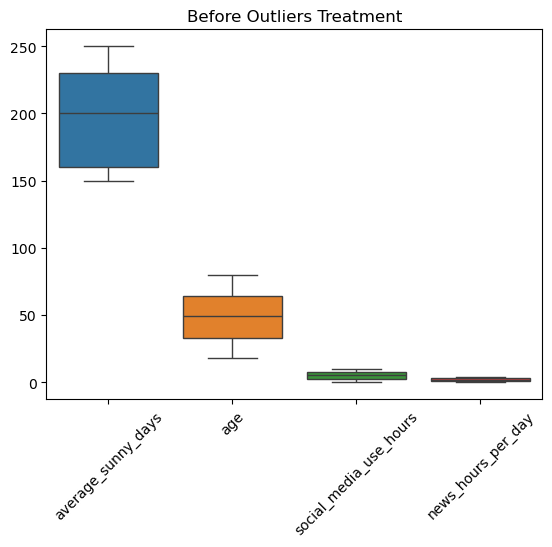

In [24]:
numeric_cols = df.select_dtypes(include='number').columns

sns.boxplot(data=df[numeric_cols])
plt.title("Before Outliers Treatment")
plt.xticks(rotation=45)
plt.show()

- There is no Outliers , So we don't have to remove it 

- Label Encoding the categorical features using mapping method

In [25]:
employment_map = {
    'Unemployed': 3,
    'Student': 2,
    'Retired': 1,
    'Employed': 0
}
marital_map = {
    'Single': 3,
    'Divorced': 2,
    'Widowed': 1,
    'Married': 0
}
education_map = {
    'High School': 3,
    'Bachelor': 2,
    'Master': 1,
    'PhD': 0
}
income_map = {
    '<1000': 4,
    '1000-2000': 3,
    '2000-3000': 2,
    '3000-5000': 1,
    '>5000': 0
}
loneliness_map = {
    'Frequent': 1,
    'Occasional': 0
}
anxiety_map = {
    'Severe': 2,
    'Moderate': 1,
    'Mild': 0
}
df['employment_status'] = df['employment_status'].map(employment_map)
df['marital_status'] = df['marital_status'].map(marital_map)
df['education_level'] = df['education_level'].map(education_map)
df['monthly_income'] = df['monthly_income'].map(income_map)
df['loneliness'] = df['loneliness'].map(loneliness_map)
df['anxiety_level'] = df['anxiety_level'].map(anxiety_map)


- Hot encoding the categorical data (country and gender)

In [26]:
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)

- Split the data into features and target variable 

In [27]:
y = df['depression_severity']
df = df.drop(columns=['depression_severity'])

- Convert boolean columns to integers to prepare for standardization

In [28]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

- stander scaling the data for the variance to be 0 and the mean to be 0

In [29]:
scaler = StandardScaler()


numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

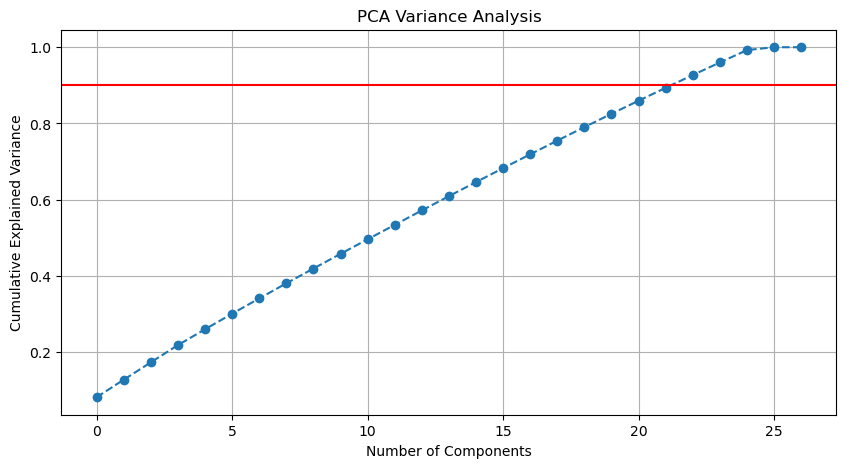

In [30]:
from sklearn.impute import SimpleImputer


numeric_df = df.select_dtypes(include=[np.number])


X_scaled = scaler.fit_transform(numeric_df)

pca = PCA()
# Impute missing values so PCA can run (PCA does not accept NaN)
imputer = SimpleImputer(strategy='median') ##
X_scaled = imputer.fit_transform(X_scaled)
pca.fit(X_scaled)


plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Variance Analysis')
plt.axhline(y=0.90, color='r', linestyle='-') 
plt.grid()
plt.show()

pca_final = PCA(n_components=0.90)
X_pca = pca_final.fit_transform(X_scaled)

      

In [31]:
print(X_pca)

[[ 2.22281934 -0.79661998 -0.61214663 ...  0.57712995  0.11858471
  -1.00392773]
 [-1.03241616 -0.58661242  1.96719334 ...  0.45399121  0.76996834
  -0.60291725]
 [ 0.07683119 -0.14821001  0.23657273 ...  0.50429575  1.20238481
   0.30819174]
 ...
 [-1.69623724 -0.74402754 -1.47238649 ...  1.23553093  0.5436988
   0.80875296]
 [-0.86191293 -0.5310304   2.21249142 ... -0.50348674 -1.5000235
  -0.64950667]
 [-0.92084482 -1.16519616  1.51606428 ...  0.40766982  0.00470098
   1.08269116]]


### PCA

- The blue curve shows cumulative explained variance vs number of principal components.
- The red horizontal line marks 90% explained variance; choose the smallest number of components where the curve crosses this line.
- `PCA(n_components=0.90)` automatically selects the minimum components that retain >= 90% of the variance.
- To see which number was chosen, run `print(pca_final.n_components_)` or check `X_pca.shape`.

Quick command to compute the crossing index manually:

`np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.90)[0][0] + 1`

## Hierarichal clustring

In [32]:
# some palletes to be used later
PALETTE  = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#F4A261', '#6A4C93']
LINK_CLR = {'ward': '#E63946', 'complete': '#2A9D8F', 'average': '#E9C46A'}

In [33]:
class HierarchicalClustering:
    """
    hierarchical clustring class takes 2 parameters
    linkage_method: string takes values 'ward', 'complete', 'average', 'single'
    metric: string takes distance metric. 'euclidean' is required for ward 
    """

    def __init__(self, linkage_method='ward', metric='euclidean'):
        if linkage_method == 'ward' and metric != 'euclidean':
            raise ValueError("Ward linkage requires euclidean metric.")
        self.linkage_method = linkage_method
        self.metric         = metric
        self.Z_             = None # linkage matrix
        self.labels_        = None # cluster labels after prediction
        self.n_clusters_    = None # number of clusters after prediction


    def fit(self, X):
        self.X_ = X
        # compute linkage matrix
        self.Z_ = linkage(X, method=self.linkage_method, metric=self.metric)
        return self


    def predict(self, n_clusters):
        if self.Z_ is None:
            raise RuntimeError("call fit() first")
        self.n_clusters_ = n_clusters
        # assign cluster labels based on the linkage matrix and desired number of clusters
        self.labels_ = fcluster(self.Z_, t=n_clusters, criterion='maxclust')
        return self.labels_


    def plot_dendrogram(self, ax=None, title=None, truncate_mode='lastp', p=30):
        if self.Z_ is None:
            raise RuntimeError("you mustcall fit() first")
        # check if ax is provided for plotting if not, create a new figure and axis
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(12, 5))

        
        dendrogram(self.Z_, ax=ax,
                   truncate_mode=truncate_mode, p=p,
                   color_threshold=0.7 * max(self.Z_[:, 2]),
                   above_threshold_color='#AAAAAA',
                   leaf_rotation=90, leaf_font_size=8)

        ax.set_title(title or f"Dendrogram — {self.linkage_method.title()} Linkage",
                     fontsize=13, fontweight='bold')
        ax.set_xlabel("Sample index (or cluster size)")
        ax.set_ylabel("Distance")
        ax.spines[['top', 'right']].set_visible(False)

        if standalone:
            plt.tight_layout(); plt.show()


    def elbow_plot(self, max_k=10, ax=None):
        if self.Z_ is None:
            raise RuntimeError("Call fit() first.")
        # get the last max_k distances from the linkage matrix and reverse them
        last = self.Z_[-max_k:, 2][::-1]
        accel = np.diff(last, 2) # compute the second derivative of the distances
        k_range = range(1, max_k + 1) # k starts from 1 because the first merge happens at k=2 clusters
        color = LINK_CLR.get(self.linkage_method, '#333333')

        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(7, 4))

        ax.plot(list(k_range), last, 'o-', color=color, linewidth=2, markersize=6)
        ax.set_xlabel("Number of Clusters (k)")
        ax.set_ylabel("Merge Distance")
        ax.set_title(f"Elbow — {self.linkage_method.title()}", fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)

        suggested_k = int(np.argmax(accel) + 2)
        ax.axvline(x=suggested_k, linestyle='--', color='red', alpha=0.7,
                   label=f"Suggested k={suggested_k}")
        ax.legend(fontsize=9)

        if standalone:
            plt.tight_layout(); plt.show()

        return suggested_k


    def silhouette_analysis(self, X, k_range=range(2, 9), ax=None):
        scores = {}
        # compute silhouette scores for each k in the specified range
        for k in k_range:
            lbl = fcluster(self.Z_, t=k, criterion='maxclust')
            scores[k] = silhouette_score(X, lbl)

        best_k = max(scores, key=scores.get)
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(8, 4))

        colors = [PALETTE[i % len(PALETTE)] for i in range(len(k_range))]
        ax.bar(list(scores.keys()), list(scores.values()),
               color=colors, edgecolor='white', linewidth=0.8)
        ax.bar(best_k, scores[best_k], color='crimson', edgecolor='white',
               label=f"Best k={best_k}  ({scores[best_k]:.3f})")
        ax.set_xlabel("Number of Clusters (k)")
        ax.set_ylabel("Silhouette Score")
        ax.set_title(f"Silhouette — {self.linkage_method.title()}", fontweight='bold')
        ax.legend(fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)

        if standalone:
            plt.tight_layout(); plt.show()

        print(f"  [{self.linkage_method.upper():8s}] "
              + "  ".join(f"k={k}: {v:.3f}" for k, v in scores.items()))
        print(f"  [{self.linkage_method.upper():8s}] Best k = {best_k}\n")
        return best_k, scores

optimal cluster analysis
  [WARD    ] k=2: 0.075  k=3: 0.088  k=4: 0.094  k=5: 0.102  k=6: 0.077  k=7: 0.064  k=8: 0.053
  [WARD    ] Best k = 5

  WARD      elbow_k=6  silhouette_k=5  → using k=5
  [COMPLETE] k=2: 0.061  k=3: 0.064  k=4: 0.070  k=5: 0.091  k=6: 0.072  k=7: 0.060  k=8: 0.054
  [COMPLETE] Best k = 5

  COMPLETE  elbow_k=2  silhouette_k=5  → using k=5
  [AVERAGE ] k=2: 0.076  k=3: 0.090  k=4: 0.093  k=5: 0.103  k=6: 0.083  k=7: 0.066  k=8: 0.056
  [AVERAGE ] Best k = 5

  AVERAGE   elbow_k=5  silhouette_k=5  → using k=5


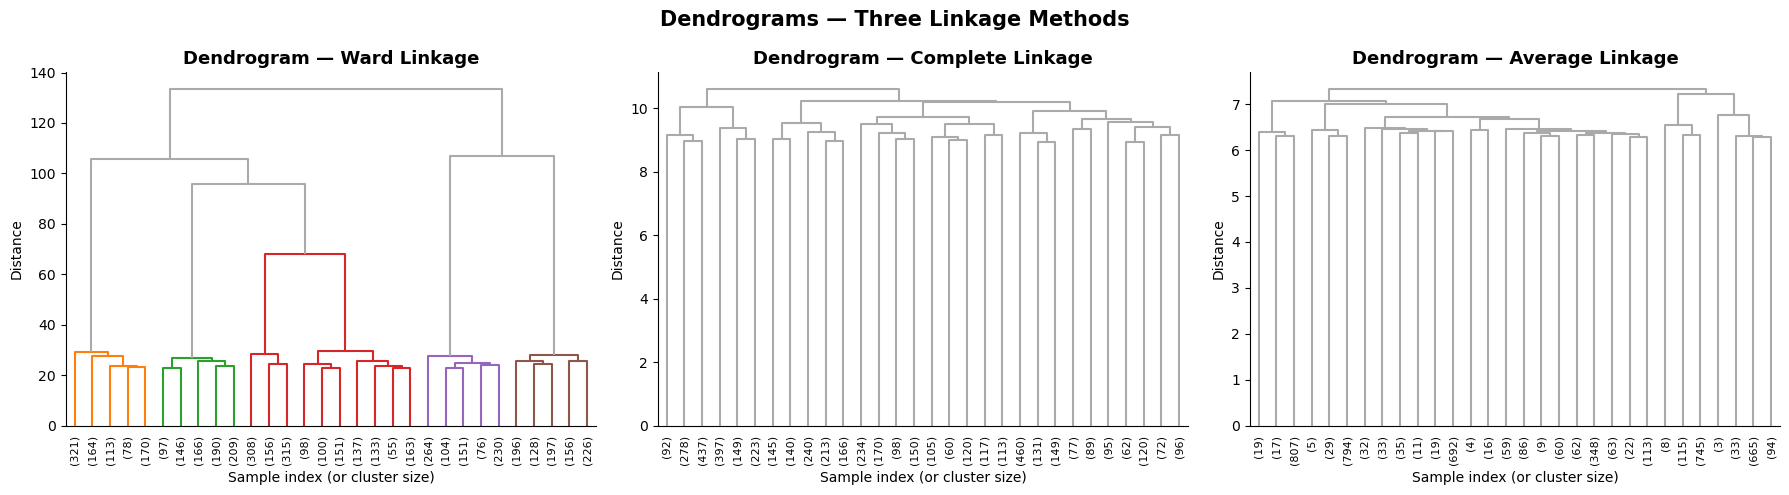

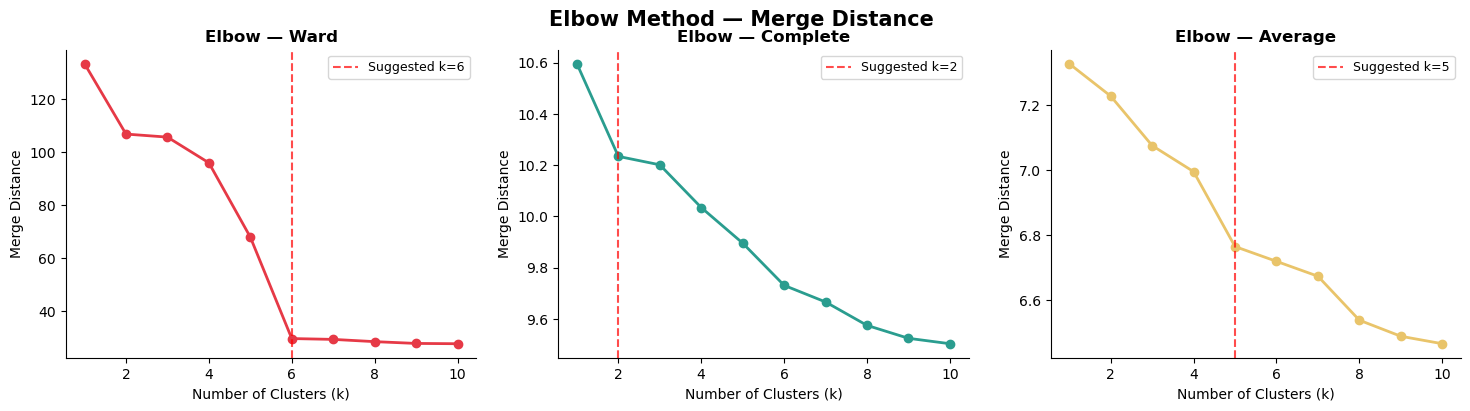

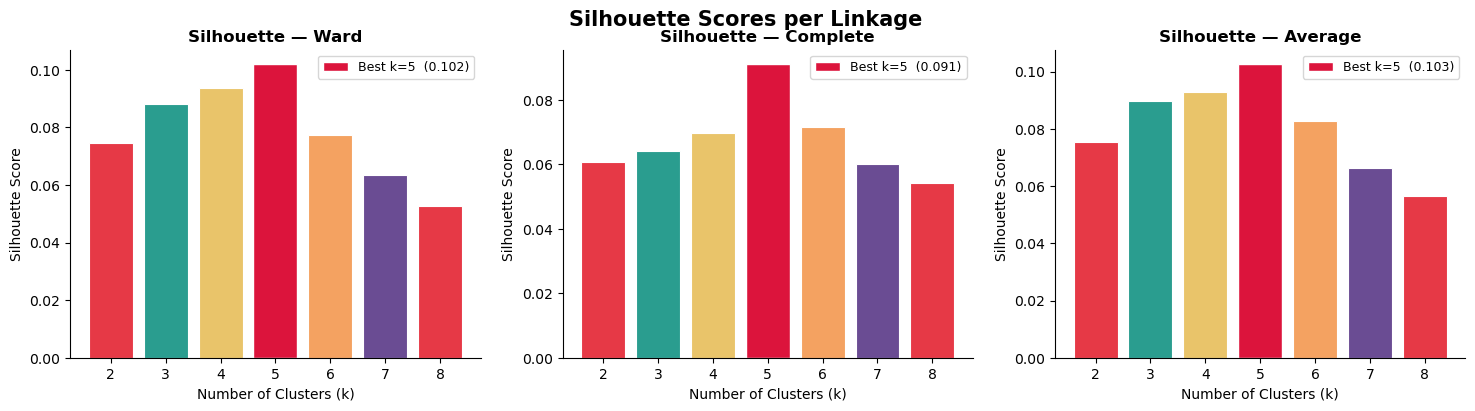

In [34]:
methods = ['ward', 'complete', 'average']
results = {}
k_range = range(2, 9)

fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("Dendrograms — Three Linkage Methods", fontsize=15, fontweight='bold')

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))
fig2.suptitle("Elbow Method — Merge Distance", fontsize=15, fontweight='bold')

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 4))
fig3.suptitle("Silhouette Scores per Linkage", fontsize=15, fontweight='bold')

print("=" * 60)
print("optimal cluster analysis")
print("=" * 60)

for i, method in enumerate(methods):
    hc = HierarchicalClustering(linkage_method=method)
    hc.fit(X_pca)

    hc.plot_dendrogram(ax=axes1[i])
    elbow_k = hc.elbow_plot(max_k=10, ax=axes2[i])
    best_k, scores = hc.silhouette_analysis(X_pca, k_range=k_range, ax=axes3[i])

    final_k = best_k # silhouette is primary; use elbow as tiebreak
    labels  = hc.predict(final_k)

    results[method] = {"model": hc, "labels": labels,
                       "best_k": final_k, "scores": scores}
    print(f"  {method.upper():8s}  elbow_k={elbow_k}  silhouette_k={best_k}  → using k={final_k}")

print("=" * 60)

for fig in [fig1, fig2, fig3]:
    fig.tight_layout(); plt.show()

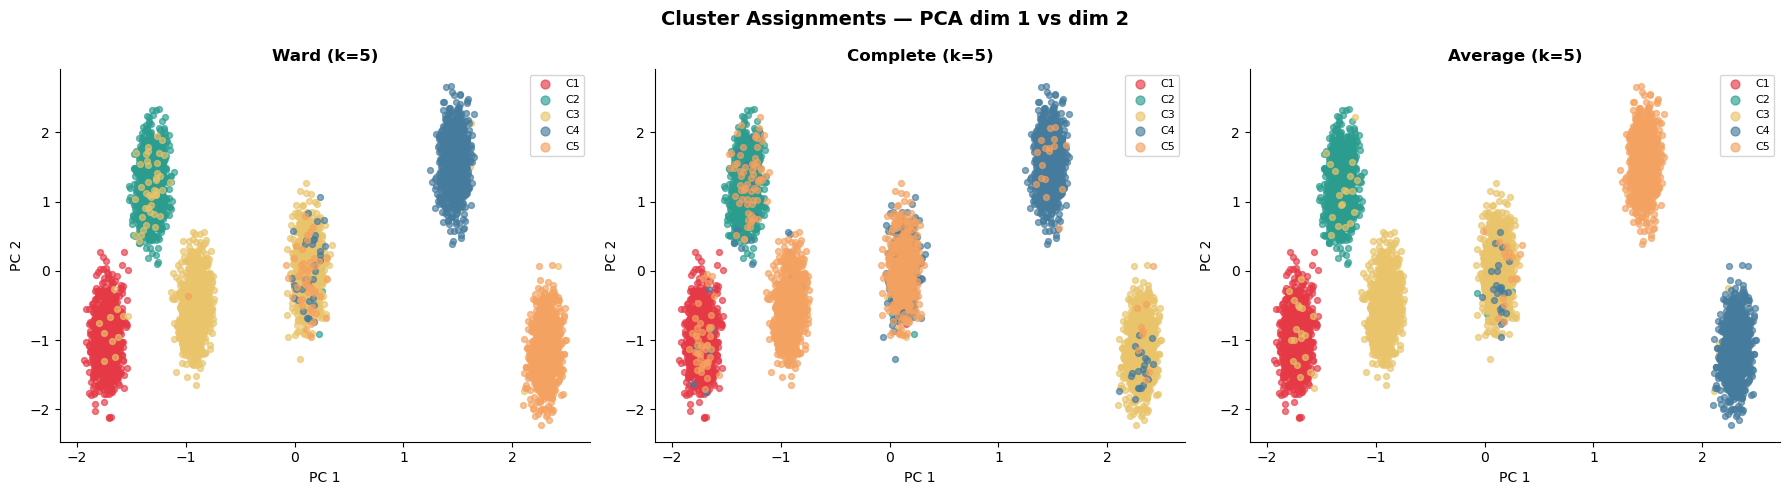

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Cluster Assignments — PCA dim 1 vs dim 2", fontsize=14, fontweight='bold')

for ax, (method, res) in zip(axes, results.items()):
    lbl, k = res['labels'], res['best_k']
    for c in np.unique(lbl):
        mask = lbl == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=18, alpha=0.65, label=f"C{c}",
                   color=PALETTE[(c - 1) % len(PALETTE)])
    ax.set_title(f"{method.title()} (k={k})", fontweight='bold')
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.legend(markerscale=1.5, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout(); plt.show()

In [36]:
#Build cluster profiles using Ward (best default method)
BEST_METHOD = 'ward'
res = results[BEST_METHOD]
hc = res['model'] 
labels = res['labels']
k = res['best_k']

profile_df  = df.copy()
profile_df['cluster'] = labels

dep_map = {'None': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
profile_df['depression_severity'] = y.map(dep_map)

summary = profile_df.groupby('cluster').mean(numeric_only=True).round(3)
summary['cluster_size'] = profile_df.groupby('cluster').size()
print(summary.T)

cluster                         1        2         3        4        5
average_sunny_days         -1.154   -0.882    -0.244    0.945    1.443
age                        -0.019    0.001     0.028    0.044   -0.074
employment_status           0.046   -0.005    -0.049    0.076   -0.020
marital_status              0.028   -0.041     0.003    0.009   -0.004
education_level             0.029   -0.040     0.003   -0.012    0.014
monthly_income                NaN      NaN       NaN      NaN      NaN
loneliness                 -0.019    0.020     0.014   -0.006   -0.020
faith                       0.040   -0.044    -0.020   -0.007    0.044
migration_background       -0.026   -0.038     0.025   -0.004    0.017
overeating                  0.001   -0.045     0.006    0.015    0.016
physical_inactivity        -0.013   -0.045     0.033   -0.059    0.047
high_sugar_intake          -0.030   -0.031     0.028   -0.019    0.023
energy_drink_consumption   -0.024    0.043    -0.006   -0.034    0.026
high_c

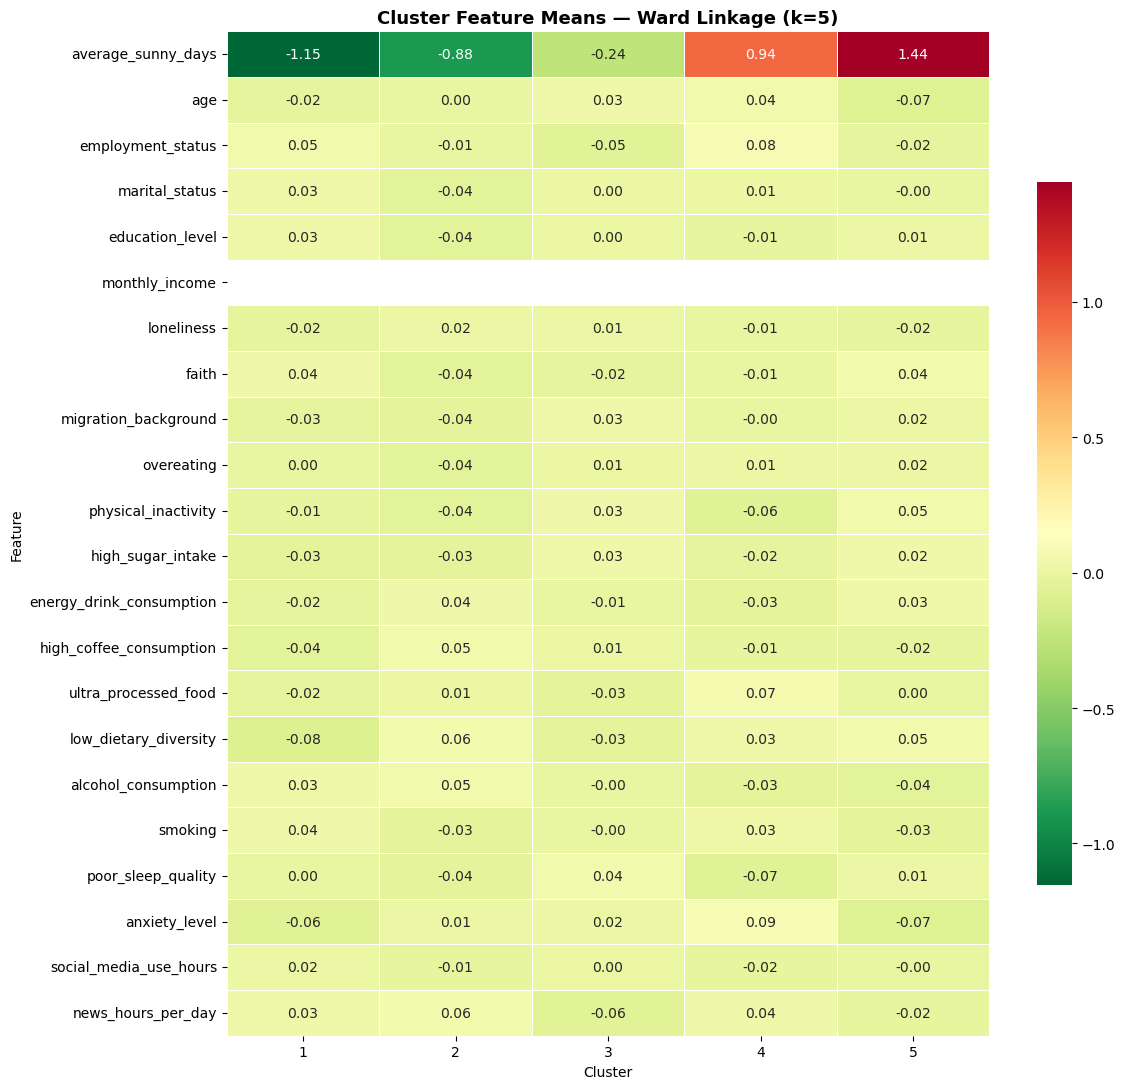

In [37]:
core_cols = [c for c in summary.columns
             if c not in ['depression_severity', 'cluster_size']
             and not c.startswith('country_')
             and not c.startswith('gender_')]

fig, ax = plt.subplots(figsize=(max(10, k * 2 + 2), 11))
sns.heatmap(summary[core_cols].T, annot=True, fmt='.2f',
            cmap='RdYlGn_r', linewidths=0.4, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title(f"Cluster Feature Means — {BEST_METHOD.title()} Linkage (k={k})",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Cluster"); ax.set_ylabel("Feature")
plt.tight_layout(); plt.show()

In [38]:
decode = {
    'employment_status': {3: 'Unemployed', 2: 'Student', 1: 'Retired', 0: 'Employed'},
    'marital_status':    {3: 'Single', 2: 'Divorced', 1: 'Widowed', 0: 'Married'},
    'education_level':   {3: 'High School', 2: 'Bachelor', 1: 'Master', 0: 'PhD'},
    'monthly_income':    {4: '<1000', 3: '1000-2000', 2: '2000-3000',
                          1: '3000-5000', 0: '>5000'},
    'loneliness':        {1: 'Frequent', 0: 'Occasional'},
    'anxiety_level':     {2: 'Severe', 1: 'Moderate', 0: 'Mild'},
}

binary_lifestyle = [
    'overeating', 'physical_inactivity', 'high_sugar_intake',
    'energy_drink_consumption', 'high_coffee_consumption',
    'ultra_processed_food', 'low_dietary_diversity',
    'alcohol_consumption', 'smoking', 'poor_sleep_quality',
    'faith', 'migration_background'
]

dep_labels = {0: 'None', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}

print("\n" + "=" * 70)
print(f"  CLUSTER INTERPRETATIONS  ({BEST_METHOD.upper()}, k={k})")
print("=" * 70)

for cid in sorted(summary.index):
    row  = summary.loc[cid]
    size = int(row.get('cluster_size', 0))
    dep  = row.get('depression_severity', float('nan'))

    print(f"\n{'─' * 70}")
    print(f"  CLUSTER {cid}  (n = {size})")
    print(f"{'─' * 70}")

    nearest_dep = min(dep_labels, key=lambda x: abs(x - dep))
    print(f"  Avg Depression Severity  : {dep_labels[nearest_dep]}  (mean={dep:.2f})")

    # demographics
    print("\n  DEMOGRAPHICS")
    for feat in ['age', 'employment_status', 'marital_status',
                 'education_level', 'monthly_income']:
        if feat not in row: continue
        val = row[feat]
        if feat in decode:
            nearest = min(decode[feat], key=lambda x: abs(x - val))
            print(f"    {feat:<22} ≈ {decode[feat][nearest]}  (mean={val:.2f})")
        else:
            print(f"    {feat:<22} = {val:.2f}")

    # lifestyle
    present = [f for f in binary_lifestyle if f in row and row[f] > 0.5]
    absent  = [f for f in binary_lifestyle if f in row and row[f] <= 0.5]
    print("\n  LIFESTYLE RISK FACTORS  (majority in cluster = mean > 0.5)")
    print(f"PRESENT: {', '.join(present) if present else 'None'}")
    print(f"ABSENT: {', '.join(absent)  if absent  else 'None'}")

    # mental / social
    print("\n  MENTAL HEALTH & SOCIAL BEHAVIOUR")
    for feat in ['loneliness', 'anxiety_level',
                 'social_media_use_hours', 'news_hours_per_day', 'average_sunny_days']:
        if feat not in row: continue
        val = row[feat]
        if feat in decode:
            nearest = min(decode[feat], key=lambda x: abs(x - val))
            print(f"    {feat:<26} ≈ {decode[feat][nearest]}  (mean={val:.2f})")
        else:
            print(f"    {feat:<26} = {val:.2f}")

    # heuristic label
    high_anxiety = row.get('anxiety_level', 0) > 0.8
    bad_sleep    = row.get('poor_sleep_quality', 0) > 0.5
    n_risks      = len(present)
    high_social  = row.get('social_media_use_hours', 0) > 6
    low_income   = row.get('monthly_income', 0) > 2.5
    unemployed   = row.get('employment_status', 0) > 2.5

    print("\n  CLUSTER LABEL")
    if high_anxiety and bad_sleep and n_risks >= 4:
        lbl = "HIGH-RISK: Severe psychosocial stress + multi-domain lifestyle impairment"
    elif high_anxiety and bad_sleep:
        lbl = "MODERATE-RISK: Anxious & sleep-deprived — candidate for mental health support"
    elif unemployed and low_income and n_risks >= 3:
        lbl = "SOCIOECONOMIC STRAIN: Financial vulnerability + sedentary unhealthy lifestyle"
    elif high_social and n_risks >= 2:
        lbl = "DIGITAL-DEPENDENT: Heavy social-media use, moderate mental health risk"
    elif n_risks <= 1 and not high_anxiety:
        lbl = "PROTECTIVE PROFILE: Few risk factors, good psychological indicators"
    else:
        lbl = "MIXED PROFILE: Moderate, heterogeneous risk — explore sub-clustering"

    print(f"{lbl}")



  CLUSTER INTERPRETATIONS  (WARD, k=5)

──────────────────────────────────────────────────────────────────────
  CLUSTER 1  (n = 846)
──────────────────────────────────────────────────────────────────────
  Avg Depression Severity  : Moderate  (mean=2.15)

  DEMOGRAPHICS
    age                    = -0.02
    employment_status      ≈ Employed  (mean=0.05)
    marital_status         ≈ Married  (mean=0.03)
    education_level        ≈ PhD  (mean=0.03)
    monthly_income         ≈ <1000  (mean=nan)

  LIFESTYLE RISK FACTORS  (majority in cluster = mean > 0.5)
PRESENT: None
ABSENT: overeating, physical_inactivity, high_sugar_intake, energy_drink_consumption, high_coffee_consumption, ultra_processed_food, low_dietary_diversity, alcohol_consumption, smoking, poor_sleep_quality, faith, migration_background

  MENTAL HEALTH & SOCIAL BEHAVIOUR
    loneliness                 ≈ Occasional  (mean=-0.02)
    anxiety_level              ≈ Mild  (mean=-0.06)
    social_media_use_hours     = 0.02
    